# Completed Final Project Notebook
## Cyber Mini-Defense Toolkit
### GET IT Program — Intro to Cybersecurity & Applied Security Foundations

This completed notebook demonstrates a beginner-friendly **Cyber Mini-Defense Toolkit** using the cybersecurity login dataset.

The toolkit includes:

1. Cybersecurity Login Dataset Analysis  
2. Suspicious Login Detection  
3. Password Hashing Tool  
4. Caesar Cipher Encryption / Decryption Tool  
5. Basic Phishing Detector  
6. Optional AI-Based Anomaly Detection Demo  

Dataset used:

`cybersecurity_login_dataset.csv`


## 1. Import Required Libraries

In [1]:
import pandas as pd
import hashlib


## 2. Load the Cybersecurity Login Dataset

Place the dataset in your project folder or inside the `data/` folder.

This notebook tries multiple common paths so it is easier to run.


In [9]:
from pathlib import Path

possible_paths = [
    Path(r"C:\Users\citguest\Downloads\cybersecurity_login_dataset (1) - cybersecurity_login_dataset (1).csv"),
    
]

dataset_path = None

for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("Dataset not found. Please place cybersecurity_login_dataset.csv in your data folder.")

logs = pd.read_csv(dataset_path)

print("Dataset loaded from:", dataset_path)
logs.head()


Dataset loaded from: C:\Users\citguest\Downloads\cybersecurity_login_dataset (1) - cybersecurity_login_dataset (1).csv


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
0,4,0,1,0,0
1,5,5,0,0,0
2,14,0,0,0,0
3,8,8,0,0,0
4,21,17,1,0,1


## 3. Explore the Dataset

This step helps us understand the structure of the cybersecurity login dataset.


In [10]:
print("Rows and columns:", logs.shape)

print("\nColumn names:")
print(logs.columns.tolist())

print("\nFirst 5 rows:")
display(logs.head())


Rows and columns: (600, 5)

Column names:
['login_attempts', 'failed_logins', 'unusual_login_hour', 'new_ip_address', 'suspicious']

First 5 rows:


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
0,4,0,1,0,0
1,5,5,0,0,0
2,14,0,0,0,0
3,8,8,0,0,0
4,21,17,1,0,1


## 4. Basic Dataset Summary

In [11]:
logs.describe()


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,13.190000,6.408333,0.511667,0.545000,0.611667
std,7.043431,5.714545,0.500281,0.498386,0.487778
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,2.000000,0.000000,0.000000,0.000000
50%,13.000000,5.000000,1.000000,1.000000,1.000000
75%,19.000000,9.250000,1.000000,1.000000,1.000000
max,25.000000,25.000000,1.000000,1.000000,1.000000


## 5. Understand the Target Column: Suspicious

The `suspicious` column indicates whether an activity pattern is suspicious.

- `0` = not suspicious
- `1` = suspicious


In [6]:
logs["suspicious"].value_counts()


suspicious
1    367
0    233
Name: count, dtype: int64

## 6. Compare Normal vs Suspicious Activity

This table shows the average behavior for normal and suspicious login activity.


In [12]:
logs.groupby("suspicious").mean()


,login_attempts,failed_logins,unusual_login_hour,new_ip_address
suspicious,,,,
0,7.733906,3.017167,0.304721,0.377682
1,16.653951,8.561308,0.643052,0.651226


## 7. Detect Failed Login Patterns

High numbers of failed logins may indicate:

- brute force attempts
- stolen credential attempts
- suspicious user behavior
- automated login attacks


In [8]:
print("Total failed logins in dataset:", logs["failed_logins"].sum())
print("Average failed logins per record:", round(logs["failed_logins"].mean(), 2))
print("Maximum failed logins in one record:", logs["failed_logins"].max())


Total failed logins in dataset: 3845
Average failed logins per record: 6.41
Maximum failed logins in one record: 25


## 8. Identify Most Suspicious Login Records

The records below show the highest number of failed login attempts.


In [13]:
top_failed = logs.sort_values(by="failed_logins", ascending=False).head(10)
top_failed


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
434,25,25,0,1,1
117,24,23,0,1,1
28,24,23,1,0,1
429,25,23,1,1,1
377,23,22,0,1,1
483,22,22,0,0,1
59,22,22,1,0,1
315,23,21,1,0,1
516,21,21,1,1,1
519,23,21,1,0,1


## 9. Create a Simple Rule-Based Detector

This detector flags login activity as suspicious if:

- failed logins are greater than 10, OR
- the login happened during an unusual hour AND came from a new IP address


In [14]:
def simple_suspicious_detector(row):
    if row["failed_logins"] > 10:
        return 1
    elif row["unusual_login_hour"] == 1 and row["new_ip_address"] == 1:
        return 1
    else:
        return 0

logs["rule_based_prediction"] = logs.apply(simple_suspicious_detector, axis=1)

logs[["login_attempts", "failed_logins", "unusual_login_hour", "new_ip_address", "suspicious", "rule_based_prediction"]].head()


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious,rule_based_prediction
0,4,0,1,0,0,0
1,5,5,0,0,0,0
2,14,0,0,0,0,0
3,8,8,0,0,0,0
4,21,17,1,0,1,1


## 10. Evaluate the Rule-Based Detector

This is a simple comparison between our rule-based prediction and the dataset label.


In [11]:
correct_predictions = (logs["suspicious"] == logs["rule_based_prediction"]).sum()
total_records = len(logs)
accuracy = correct_predictions / total_records

print("Correct predictions:", correct_predictions)
print("Total records:", total_records)
print("Rule-based accuracy:", round(accuracy, 3))


Correct predictions: 491
Total records: 600
Rule-based accuracy: 0.818


## 11. Security Findings Summary

This section summarizes the most important findings from the dataset.


In [15]:
suspicious_count = logs["suspicious"].sum()
normal_count = len(logs) - suspicious_count

print("CYBERSECURITY LOGIN ANALYSIS SUMMARY")
print("-----------------------------------")
print("Total records:", len(logs))
print("Suspicious records:", suspicious_count)
print("Normal records:", normal_count)
print("Highest failed login count:", logs["failed_logins"].max())
print("Average failed logins for suspicious records:", round(logs[logs["suspicious"] == 1]["failed_logins"].mean(), 2))
print("Average failed logins for normal records:", round(logs[logs["suspicious"] == 0]["failed_logins"].mean(), 2))


CYBERSECURITY LOGIN ANALYSIS SUMMARY
-----------------------------------
Total records: 600
Suspicious records: 367
Normal records: 233
Highest failed login count: 25
Average failed logins for suspicious records: 8.56
Average failed logins for normal records: 3.02


## 12. Optional Visualization

This chart compares suspicious and normal records.


<Axes: title={'center': 'Normal vs Suspicious Login Records'}, xlabel='suspicious'>

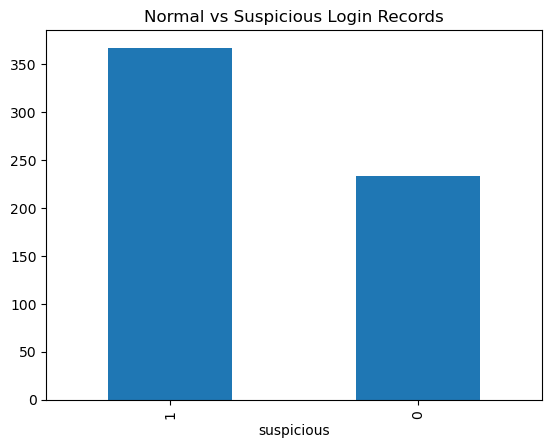

In [16]:
logs["suspicious"].value_counts().plot(kind="bar", title="Normal vs Suspicious Login Records")


# Toolkit Component 1 — Password Hashing Tool

This tool demonstrates how passwords can be transformed into SHA-256 hashes.


In [17]:
def hash_password(password):
    return hashlib.sha256(password.encode()).hexdigest()

sample_passwords = ["abc", "MyP@ss123", "pass1234"]

for password in sample_passwords:
    print("Password:", password)
    print("SHA-256 Hash:", hash_password(password))
    print("-" * 60)


Password: abc
SHA-256 Hash: ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
------------------------------------------------------------
Password: MyP@ss123
SHA-256 Hash: 15783160182ec7936c791824ec5ff330cb5c41dc5241b2bd95e50e65e027c3a0
------------------------------------------------------------
Password: pass1234
SHA-256 Hash: bd94dcda26fccb4e68d6a31f9b5aac0b571ae266d822620e901ef7ebe3a11d4f
------------------------------------------------------------


# Toolkit Component 2 — Caesar Cipher Encryption / Decryption Tool

This tool demonstrates basic encryption and decryption using a Caesar Cipher.


In [18]:
def caesar_encrypt(text, shift):
    result = ""

    for char in text:
        if char.isalpha():
            base = 65 if char.isupper() else 97
            result += chr((ord(char) - base + shift) % 26 + base)
        else:
            result += char

    return result

def caesar_decrypt(text, shift):
    return caesar_encrypt(text, -shift)

message = "Security 101"
shift = 3

encrypted_message = caesar_encrypt(message, shift)
decrypted_message = caesar_decrypt(encrypted_message, shift)

print("Original message:", message)
print("Encrypted message:", encrypted_message)
print("Decrypted message:", decrypted_message)


Original message: Security 101
Encrypted message: Vhfxulwb 101
Decrypted message: Security 101


# Toolkit Component 3 — Basic Phishing Detector

This tool checks whether a message contains common phishing keywords.


In [21]:
def phishing_detector(message):
    keywords = ["urgent", "verify", "click", "password", "win", "claim", "locked", "account", "gift card"]

    for word in keywords:
        if word in message.lower():
            return "Potential phishing message detected"

    return "No obvious phishing keywords detected"

messages = [
    "Your account has been locked. Click here to verify your password.",
    "Hi, just checking in about tomorrow's meeting.",
    "You have won a $1000 gift card! Claim now."
    "You have won a free gift card! Claim now."


]

for msg in messages:
    print("Message:", msg)
    print("Result:", phishing_detector(msg))
    print("-" * 60)


Message: Your account has been locked. Click here to verify your password.
Result: Potential phishing message detected
------------------------------------------------------------
Message: Hi, just checking in about tomorrow's meeting.
Result: No obvious phishing keywords detected
------------------------------------------------------------
Message: You have won a $1000 gift card! Claim now.You have won a free gift card! Claim now.
Result: Potential phishing message detected
------------------------------------------------------------


# Optional Toolkit Component 4 — AI-Based Anomaly Detection

This optional section uses Isolation Forest to detect unusual login activity.

If `scikit-learn` is not installed, run:

`!pip install scikit-learn`


In [22]:
try:
    from sklearn.ensemble import IsolationForest

    features = logs[["login_attempts", "failed_logins", "unusual_login_hour", "new_ip_address"]]

    model = IsolationForest(contamination=0.2, random_state=42)
    logs["ai_anomaly_prediction"] = model.fit_predict(features)

    # In Isolation Forest:
    # -1 = anomaly
    # 1 = normal
    logs["ai_flag"] = logs["ai_anomaly_prediction"].apply(lambda x: "Anomaly" if x == -1 else "Normal")

    print(logs["ai_flag"].value_counts())
    display(logs.head())

except ImportError:
    print("scikit-learn is not installed. Run: !pip install scikit-learn")


ai_flag
Normal     480
Anomaly    120
Name: count, dtype: int64


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious,rule_based_prediction,ai_anomaly_prediction,ai_flag
0,4,0,1,0,0,0,-1,Anomaly
1,5,5,0,0,0,0,1,Normal
2,14,0,0,0,0,0,1,Normal
3,8,8,0,0,0,0,-1,Anomaly
4,21,17,1,0,1,1,1,Normal


# Final Project Reflection

Answer the following questions before submission.

## 1. What suspicious activity did you find?

The dataset included many records marked as suspicious. Suspicious records generally had higher failed login counts, unusual login hours, and new IP address activity.

## 2. Which features helped identify suspicious behavior?

The most useful features were:

- failed_logins
- login_attempts
- unusual_login_hour
- new_ip_address

## 3. How could cybersecurity analysts use this?

Cybersecurity analysts could use this type of log analysis to detect possible brute force attacks, unusual access attempts, or suspicious account behavior.

## 4. How could AI help?

AI can help analyze large amounts of login data and detect unusual patterns faster than manual review.

## 5. What is one risk of relying only on AI?

AI may create false positives or miss real threats. Human review is still important for responsible cybersecurity decisions.


# Final Project Reflection

Answer the following questions before submission.

## 1. What suspicious activity did you find?

The dataset included many records marked as suspicious. Suspicious records generally had higher failed login counts, unusual login hours, and new IP address activity.

## 2. Which features helped identify suspicious behavior?

The most useful features were:

- failed_logins
- login_attempts
- unusual_login_hour
- new_ip_address

## 3. How could cybersecurity analysts use this?

Cybersecurity analysts could use this type of log analysis to detect possible brute force attacks, unusual access attempts, or suspicious account behavior.

## 4. How could AI help?

AI can help analyze large amounts of login data and detect unusual patterns faster than manual review.

## 5. What is one risk of relying only on AI?

AI may create false positives or miss real threats. Human review is still important for responsible cybersecurity decisions.


In [26]:
Answer to Question 1 The one i found suspicious was the 21 failed login attempts 17 failed logins and 1 unusal login hour
Answer to Question 2 the feutures that were the most useful was the failed logins and the login attemps
Answer to Question 3 Cybersecurity analist coult use this type of analyisis to decect diffrent types of attacks 
Answer to Question 4 AI can help analyze lots of data and detect patterns a lot faster than human preformance 
Answer to Question 5 One of ris of relying on AI is that i can miss diagonse threats or create false alarms.


SyntaxError: invalid syntax (4155512404.py, line 1)

# README Summary Text

You may copy this into your GitHub README.

```markdown
## Final Project: Cyber Mini-Defense Toolkit

This project uses a cybersecurity login dataset to identify suspicious login activity. The toolkit includes:

- Login dataset analysis
- Suspicious activity detection
- Password hashing tool
- Caesar Cipher encryption/decryption tool
- Basic phishing detector
- Optional anomaly detection demo

The project demonstrates foundational cybersecurity skills including password security, encryption, log analysis, phishing awareness, and AI-assisted threat detection.
```


# ✅ Final Project Checklist

Before submitting, make sure your GitHub repository includes:

- [ ] Completed notebook
- [ ] Dataset in the `data/` folder
- [ ] README.md
- [ ] Reflection file
- [ ] At least 3 toolkit components
- [ ] Screenshot of GitHub project structure
- [ ] GitHub link submitted in Google Classroom
